<a href="https://colab.research.google.com/github/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/blob/main/notebook/Producao_Nacional_Petroleo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**PUC-RIO** - Pós-Graduação em Ciência de Dados e Analytics

**Nome:** _Rosângela Gomes André_

**Matrícula:** _4052025002132_

**Data:** _05/07/2026_

**Dataset:** _[Produção de Petróleo e gás natural (ANP)](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos) / [Produção por Poços](https://cdp.anp.gov.br/ords/r/cdp_apex/consulta-dados-publicos-cdp/consulta-produ%C3%A7%C3%A3o-por-po%C3%A7o)_

**Tipo de problema:** _Séries Temporais_ / _forecasting com abordagem supervisionada de regressão_

# 1. Definição do Problema

## 1.1 Descrição do Problema
A indústria de petróleo e gás gera um volume massivo de dados operacionais e séries históricas mensais sobre a extração de recursos. No Brasil, a ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis) disponibiliza publicamente esses dados em nível de poço, contendo volumes de produção (óleo, condensado, gás, água e outras informações técnicas), identificação do campo, bacia, operador e período de referência.

Embora a base original seja granular por poço, **este MVP realiza a consolidação e previsão no nível campo-mês**. Esta abordagem técnica mitiga ruídos e oscilações severas típicas de poços individuais — como paradas operacionais temporárias, manutenções e intervenções, resultando em séries históricas mais estáveis, menos ruidosas e adequadas para o planejamento analítico e estratégico.

## 1.1.1 O Problema e Desafio de Modelagem
A produção de um campo pode variar por maturidade do reservatório, declínio natural, entrada de novos poços, parada de poços existentes, intervenções operacionais, mudança de estratégia de produção e restrições de infraestrutura. Parte desses fatores não está explicitamente disponível nos dados públicos, mas seus efeitos e padrões comportamentais podem aparecer indiretamente nas séries históricas de produção.

O problema central deste MVP é prever a produção mensal de óleo de um campo a partir do histórico observado nos meses anteriores. A solução não pretende substituir modelos complexos de engenharia de reservatórios nem previsões oficiais de produção. O objetivo principal é demonstrar um fluxo completo, reprodutível e criticamente avaliado de Machine Learning aplicado a uma base pública real da indústria.

## 1.2 Objetivo do MVP

O objetivo principal deste MVP é construir, avaliar e comparar modelos de Machine Learning capazes de prever a produção mensal de óleo por campo para os próximos **5 anos (60 meses)**, integrando variáveis de gás como atributos alvos secundários para projetar o comportamento simultâneo das curvas de hidrocarbonetos. A modelagem utilizará o histórico de dados públicos da ANP originalmente coletados por poço e consolidados no nível campo-mês.

Para alcançar esse objetivo de forma rigorosa e criticamente avaliada, o projeto compreende as seguintes etapas específicas:

* **Consolidação Multivariada de Dados:** Tratar e agregar a base histórica da ANP do nível de poço para o nível estável de campo-mês, estruturando as séries temporais das variáveis de **Óleo** (alvo principal), **Óleo Condensado**, **Gás Natural**, **Gás Associado** e **Gás Não Associado** (alvos secundários).
* **Modelagem Preditiva Multi-Output:** Desenvolver e treinar modelos candidatos de Machine Learning estruturados para capturar a interdependência entre as curvas e projetar os volumes acumulados para o horizonte de 5 anos.
* **Avaliação de Desempenho:** Comparar os modelos preditivos desenvolvidos contra abordagens de referência (*baselines* temporais simples), mensurando a acurácia de forma combinada e individual em dados não utilizados no treinamento (dados não vistos).
* **Análise Crítica:** Identificar e discutir as limitações técnicas e práticas da abordagem, avaliando criticamente como a ausência de variáveis físicas, geológicas e operacionais (não disponíveis nos dados públicos) limita o modelo de Machine Learning puro, distinguindo sua aplicação analítica de curto/médio prazo das abordagens físicas tradicionais da engenharia de reservatórios.

## 1.3 Tipo de Problema

**Tipo Escolhido:** Previsão de Séries Temporais (*Time Series Forecasting*) estruturada como Regressão Supervisionada Tabular (Multi-Output).

**Justificativa:**
O projeto lida com a previsão de valores numéricos contínuos (volumes mensais de produção de hidrocarbonetos) distribuídos ao longo do tempo, onde a ordem cronológica dos dados é fundamental para o aprendizado do modelo. O comportamento futuro das curvas depende diretamente do histórico temporal anterior e de sua dinâmica de declínio.

Para viabilizar a aplicação de algoritmos clássicos e avançados de Machine Learning neste MVP, a dimensão temporal será tratada por meio da transformação das séries históricas em uma estrutura tabular supervisionada. Isso será feito através da engenharia de atributos (*feature engineering*), utilizando:
* **Defasagens (*Lags*):** Valores de produção de meses anteriores.
* **Janelas Deslizantes:** Médias móveis e métricas estatísticas acumuladas que capturam a tendência de declínio do campo.
* **Atributos de Calendário/Sazonalidade:** Variáveis que mapeiam o comportamento temporal e padrões cíclicos.
* **Atributos Estáticos do Campo:** Identificação do ativo, bacia e operador.

**Premissas de Validação:**
Por se tratar de um problema estritamente temporal, o ordenamento cronológico dos dados será rigorosamente respeitado na separação entre os conjuntos de treinamento, validação e teste. Serão evitadas técnicas tradicionais de embaralhamento (*shuffle* ou *K-Fold* padrão), adotando-se uma divisão temporal (como *Time Series Split*). Essa estratégia impede o vazamento de dados (*data leakage*) do futuro para o passado e garante que os modelos candidatos sejam avaliados de forma justa em períodos futuros não vistos durante o treinamento, simulando com realismo a projeção do horizonte de 5 anos.

## 1.4 Premissas, Hipóteses e Critérios de Sucesso

### Premissas do Projeto
* **Suficiência dos Dados Públicos:** Os dados históricos disponibilizados publicamente pela ANP possuem os atributos e o volume necessários para a construção de um MVP analítico e exploratório.
* **Redução de Ruído por Agregação:** A consolidação dos dados originais de poço para o nível campo-mês atenua significativamente as oscilações operacionais extremas de poços individuais, criando uma série temporal mais estável e tratável para modelagem.
* **Sinal Histórico Parcial:** A produção histórica agregada carrega sinais intrínsecos de tendência, ciclicidade e curvas de declínio natural que podem ser parcialmente capturados por algoritmos supervisionados.
* **Limitação Informacional Reconhecida:** Eventos operacionais críticos (como decisões comerciais das operadoras, restrições físicas de plataformas ou intervenções planejadas em poços) não estão disponíveis nos dados públicos e impõem um limite natural à acurácia do modelo.

### Hipóteses Iniciais
* **Suficiência Preditiva Temporal:** As variáveis defasadas (*lags*), médias móveis e atributos de sazonalidade derivados da própria série histórica são preditores eficazes para projetar a tendência de comportamento futuro.
* **Correlação Multivariável:** Existe uma forte interdependência entre a curva de Óleo (alvo principal) e as demais curvas de hidrocarbonetos (alvos secundários, como o gás associado e condensado), permitindo que modelos estruturados capturem dinâmicas conjuntas de produção de forma mais consistente do que projeções isoladas.
* **Superioridade do Machine Learning:** Modelos supervisionados não lineares baseados em árvores (como XGBoost ou LightGBM) adaptados para o contexto temporal superarão as abordagens de referência (*baselines* estatísticos simples) ao longo do horizonte de 5 anos projetados.

### Critérios de Sucesso

| Critério | Definição |
| :--- | :--- |
| **Métrica Principal** | **WAPE / WMAPE (Erro Percentual Absoluto Ponderado):**<br><br>• Adotado por ser estatisticamente robusto para séries temporais que contêm valores zerados, evitando divisões por zero.<br>• Pondera o erro proporcionalmente ao volume de produção de cada campo, refletindo o real impacto logístico e financeiro para o planejamento de longo prazo. |
| **Métricas Complementares** | **MAE (Erro Absoluto Médio):** Para monitorar o erro médio absoluto na unidade física (barris/dia).<br><br>**RMSE (Raiz do Erro Quadrático Médio):** Aplicado para penalizar com maior rigor grandes desvios e erros severos de previsão nas curvas de produção. |
| **Resultado Mínimo Esperado** | Superar o melhor *baseline* temporal simples (como o modelo de persistência ou média móvel), obtendo uma **redução de pelo menos 10% a 15% no valor do WAPE** global no conjunto de teste. |
| **Restrição Metodológica** | Respeitar rigorosamente a divisão cronológica dos dados (validação temporal), sem qualquer tipo de embaralhamento (*shuffle* aleatório) para garantir uma avaliação realista e evitar vazamento de dados (*data leakage*). |
| **Restrição Prática** | O pipeline completo deve ser leve, reprodutível e executável no ambiente padrão do **Google Colab**, sem depender de uploads manuais complexos ou infraestrutura de nuvem de alto custo. |
| **Restrição de Uso** | O resultado gerado pelo modelo deve ser interpretado estritamente como uma **projeção analítica exploratória acadêmica**, não possuindo caráter de previsão oficial ou substituição da engenharia de reservatórios. |

## 2. Ambiente, Bibliotecas e Reprodutibilidade

Esta seção reúne o ecossistema de software, pacotes e as configurações de semente (*seed*) necessárias para garantir que a execução deste notebook produza exatamente os mesmos resultados em qualquer ambiente compatível, priorizando a execução nativa no Google Colab.

### Estrutura de Armazenamento e Carga de Dados
Para garantir a máxima reprodutibilidade e eliminar a necessidade de uploads manuais ou configurações locais, **o dataset completo foi centralizado e disponibilizado no repositório público do GitHub**:
* **Repositório:** [rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS](https://github.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/tree/main/data)

A base histórica apresenta um desafio de padronização estrutural (*data wrangling*): alguns anos estão consolidados em um único arquivo `.csv`, enquanto outros estão fragmentados em arquivos `.csv` mensais dentro da pasta `/data`. Além disso, os formatos e disposições das colunas variam sutilmente entre os anos. No entanto, o pipeline foi projetado para mapear, unificar e ler esses arquivos diretamente da URL pública, extraindo as colunas essenciais (comuns a todos os períodos) durante a etapa de ingestão para garantir a integridade da série temporal.

### Bibliotecas Utilizadas
O pipeline foi desenvolvido utilizando a linguagem Python, apoiando-se nos seguintes blocos de pacotes:

* **Conexão e Requisição de Dados:** `requests` (para comunicação assíncrona e validação do download dos arquivos `.csv` brutos armazenados no GitHub).
* **Manipulação, Ingestão e Padronização:** `pandas` (essencial para ler os arquivos via URL *raw*, mapear colunas divergentes, concatenar os arquivos anuais/mensais e realizar a agregação final no nível campo-mês) e `numpy` (para suporte matemático).
* **Visualização de Dados:** `matplotlib` (essencial para plotar as curvas de declínio e as projeções futuras de 5 anos).
* **Modelagem Preditiva e Machine Learning:** `scikit-learn` (utilizado para divisão temporal via `TimeSeriesSplit`, pré-processamento blindado contra vazamento de dados via `Pipeline`, modelos de referência e algoritmos candidatos como `RandomForestRegressor` e `HistGradientBoostingRegressor`).


In [38]:
# === Setup Básico e Reprodutibilidade ===
import os
import re
import io
import sys
import time
import math
import random
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sklearn

# Pré-processamento, Validação e Pipelines do Scikit-Learn
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos (Baseline e Candidatos Avançados)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Métricas de Avaliação e Scorer customizado para o WAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer

# Ignorar avisos/warnings para limpar o output do notebook
warnings.filterwarnings("ignore")

# Configuração de semente fixa para reprodutibilidade estrita
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configurações de exibição do Pandas para facilitar a análise das colunas unificadas
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# URL Base do GitHub em formato RAW para leitura direta via Pandas das tabelas da pasta /data
GITHUB_RAW_URL = "https://raw.githubusercontent.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/main/data/"

# Implementação matemática da função WAPE/WMAPE para o ecossistema Scikit-Learn
def wape_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    total_actual = np.sum(y_true)
    if total_actual == 0:
        return 0.0
    return np.sum(np.abs(y_true - y_pred)) / total_actual

# Criando o scorer oficial para usar no RandomizedSearchCV
wape_scorer = make_scorer(wape_score, greater_is_better=False)

# Confirmação do ambiente de execução
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Ambiente configurado para leitura direta do GitHub.")
print(f"Semente Global (Seed) configurada: {SEED}")

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Ambiente configurado para leitura direta do GitHub.
Semente Global (Seed) configurada: 42


## 2.1 Dependências adicionais

Este MVP foi projetado para ser **totalmente autossuficiente**, utilizando exclusivamente as versões estáveis das bibliotecas que já vêm pré-instaladas no ambiente padrão do **Google Colab**.

Como os dados são consumidos diretamente do repositório do GitHub e a modelagem utiliza algoritmos suportados nativamente pelo ecossistema do Colab (como as suítes do Scikit-Learn e pacotes de visualização), **não é necessária a instalação de pacotes externos via gerenciador de dependências**. Isso minimiza o risco de quebras por incompatibilidade de versões (*pipeline breaking*) durante a execução e correção do artefato.

Caso o script seja executado em um ambiente local ou container minimalista que não disponha dessas ferramentas básicas, a célula de código abaixo pode ser descomentada para garantir a conformidade do ecossistema.


In [18]:
# === Dependências Opcionais ===
# O ambiente padrão do Google Colab já possui todos os pacotes necessários pré-instalados.
# Descomente a linha abaixo APENAS se estiver rodando o projeto em um ambiente local muito restrito.

# !pip install -q pandas numpy matplotlib seaborn scikit-learn requests

## 2.2 Funções auxiliares

Esta seção centraliza o desenvolvimento de funções modulares projetadas para mitigar dois desafios específicos deste MVP:
1. **Tratamento e Unificação de Dados (*Data Wrangling*):** Como os históricos anuais da ANP armazenados no GitHub variam em termos de separadores decimais (padrão pt-BR com vírgulas versus padrão internacional com pontos), codificação e nomenclatura de colunas, foram criadas funções robustas de normalização de strings e parsing de strings numéricas.
2. **Avaliação Padronizada de Modelos:** Funções utilitárias que centralizam e calculam de forma limpa a suíte exata de métricas de sucesso estabelecidas (**WAPE**, **MAE** e **RMSE**), gerando relatórios tabulares comparativos entre os modelos preditivos e os *baselines*.


In [39]:
# === 2.2 Funções Auxiliares do Pipeline ===

def normalizar_texto(texto):
    """
    Remove acentos, padroniza strings para maiúsculas e substitui caracteres
    especiais e espaços por underscores, facilitando a unificação de colunas da ANP.
    """
    if pd.isna(texto):
        return ""
    texto = str(texto).strip()
    texto = texto.replace("³", "3").replace("²", "2")
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = texto.upper()
    texto = re.sub(r"[^A-Z0-9]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


def normalizar_colunas(df):
    """Aplica a padronização de texto de forma vetorizada nos headers do DataFrame."""
    df = df.copy()
    df.columns = [normalizar_texto(c) for c in df.columns]
    return df


def converter_numero(valor):
    """
    Converte strings numéricas em formatos brasileiro ou internacional para float.
    Trata casos de strings poluídas com espaços ou múltiplos separadores.
    Exemplos mapeados: '1.234,56' -> 1234.56 | '1234,56' -> 1234.56
    """
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip()
    if valor in ["", "-", "NA", "N/A", "NULL", "NONE", "NAN", "NULO"]:
        return np.nan

    valor = valor.replace(" ", "")
    valor = re.sub(r"[^0-9,\.\-]", "", valor)

    if "," in valor and "." in valor:
        if valor.rfind(",") > valor.rfind("."):
            valor = valor.replace(".", "").replace(",", ".")
        else:
            valor = valor.replace(",", "")
    elif "," in valor:
        valor = valor.replace(",", ".")

    try:
        return float(valor)
    except Exception:
        return np.nan


def calcular_wape(y_true, y_pred):
    """
    Calcula o Weighted Absolute Percentage Error (WAPE).
    Métrica principal: robusta a zeros e ponderada pelo volume real produzido.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return (np.sum(np.abs(y_true - y_pred)) / denom) * 100


def evaluate_regression(y_true, y_pred):
    """
    Centraliza o cálculo e consolida a suíte exata de métricas do MVP.
    Aplica um piso zero nas predições para evitar volumes negativos fisicamente impossíveis.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0) # Garante produção >= 0

    mse = mean_squared_error(y_true, y_pred)
    return {
        "WAPE_%": calcular_wape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse)
    }


def show_results_table(results_dict, sort_by="WAPE_%"):
    """
    Consolida o dicionário histórico de experimentos em um DataFrame ordenado,
    facilitando a comparação direta de desempenho com base no critério de sucesso.
    """
    df_res = pd.DataFrame(results_dict).T
    if sort_by in df_res.columns:
        df_res = df_res.sort_values(sort_by)
    return df_res

# Mapeamento semântico de segurança para o pipeline
wmape = calcular_wape

# 3. Seleção e Carga dos Dados

Esta secção detalha a origem dos dados públicos utilizados no MVP, as justificativas para a escolha da base, os aspetos regulatórios envolvidos e a implementação do pipeline de extração automatizada das informações a partir do repositório do projeto.

### 3.1 Fonte dos Dados

* **Nome do dataset:** Dados de Produção de Petróleo e Gás Natural (Recorte Offshore - Mar).
* **Link da fonte oficial:** [Produção de Petróleo e Gás Natural (ANP) / Painel de Produção por Poços](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos).
* **Por que este dataset foi escolhido:** O conjunto de dados concentra o histórico oficial, consolidado e auditado da produção nacional de hidrocarbonetos pela ANP. Ele fornece o comportamento volumétrico real e desagregado das curvas que compõem o escopo preditivo deste MVP, servindo como base sólida para o treinamento de algoritmos de séries temporais de longo prazo.

* **Restrições e Condições Consideradas:** O recorte considera os dados mensais para mitigar ruídos operacionais de curtíssimo prazo e foca especificamente no ambiente offshore (**produção de mar**), que representa o vetor estratégico de maior investimento e volume produtivo do país. Para viabilizar a estabilidade, reprodutibilidade e velocidade do pipeline no ambiente de execução, a ampla série histórica de **21 anos (2005 a 2025)** foi hospedada no repositório público do GitHub do projeto, respeitando as formatações originais disponibilizadas historicamente pela agência reguladora.

* **Ética, Privacidade e Licença:** O dataset é classificado como **Dados Abertos Governamentais**, sob a licença *Creative Commons Attribution* (CC BY). Por tratar-se de dados volumétricos operacionais agregados por ativos e poços institucionais, não existem informações sensíveis de indivíduos, violações de privacidade ou quebras de confidencialidade comercial, respeitando integralmente os preceitos éticos e as diretrizes da LGPD (Lei Geral de Proteção de Dados).

### 3.2 Carga dos Dados

O bloco abaixo automatiza a extração e a consolidação do extenso histórico de dados de produção (2005-2025). O pipeline foi projetado com uma arquitetura adaptativa e resiliente para lidar com a **natureza híbrida e a evolução estrutural dos layouts da ANP** ao longo das décadas. A esteira realiza uma varredura cronológica inteligente dividida por períodos governados pelas seguintes regras de negócio:

* **De 2005 a 2009 e de 2016 a 2018:** Ingestão de arquivos únicos consolidados anualmente no formato Excel (`.xlsx`), com salto de cabeçalhos institucionais.
* **De 2010 a 2015 e de 2019 a 2020:** Ingestão de arquivos fracionados mensalmente (`ANO_MES`) no formato Excel (`.xlsx`), com salto de cabeçalhos institucionais.
* **De 2021 a 2025:** Ingestão de arquivos fracionados mensalmente (`ANO_MES`) no formato nativo `CSV`, lidos diretamente a partir do topo.

In [58]:
# === 3.2 Ingestão Consolidada Definitiva - Gabarito Oficial de 50 Colunas (2005 - 2025) ===
import pandas as pd
import numpy as np

base_url = "https://raw.githubusercontent.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/main/data"
meses_producao = [str(i).zfill(2) for i in range(1, 13)]

# Gabarito Oficial Absoluto com as 50 colunas exatas extraídas do seu CSV original + as duas criadas no final
GABARITO_50_COLUNAS = [
    'ESTADO', 'BACIA', 'NOME_POCO_ANP', 'NOME_POCO_OPERADOR', 'CAMPO', 'OPERADOR',
    'NUMERO_DO_CONTRATO', 'PERIODO', 'OLEO_BBL_DIA', 'CONDENSADO_BBL_DIA', 'PETROLEO_BBL_DIA',
    'GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC', 'GAS_NATURAL_MM3_DIA_TOTAL',
    'VOLUME_GAS_ROYALTIES_M3_MES', 'AGUA_BBL_DIA', 'INSTALACAO_DESTINO', 'TIPO_INSTALACAO',
    'TEMPO_DE_PRODUCAO_HS_POR_MES', 'PERIODO_DA_CARGA', 'CORRENTE', 'GRAU_API',
    'FRACOES_DE_DESTILADOS_LEV_CORTE', 'FRACOES_DE_DESTILADOS_LEV_VOLUME',
    'FRACOES_DE_DESTILADOS_MED_CORTE', 'FRACOES_DE_DESTILADOS_MED_VOLUME',
    'FRACOES_DE_DESTILADOS_PES_CORTE', 'FRACOES_DE_DESTILADOS_PES_VOLUME',
    'VOLUME_METANO', 'VOLUME_ETANO', 'VOLUME_PROPANO', 'VOLUME_ISO-BUTANO',
    'VOLUME_BUTANO', 'VOLUME_ISO-PENTANO', 'VOLUME_N-PENTANO', 'VOLUME_HEXANOS',
    'VOLUME_HEPTANOS', 'VOLUME_OCTANOS', 'VOLUME_NONANOS', 'VOLUME_DECANOS',
    'VOLUME_UNDECANOS', 'VOLUME_OXIGENIO',
    'PERC_EM_VOLUMES_NITROGENIO', 'PERC_EM_VOLUMES_GAS_CARBONICO',
    'DENSIDADE_GLP_GAS', 'DENSIDADE_GLP_LIQUIDO', 'PCS_GP_KJ_M3', 'DATA_DE_ATUALIZACAO',
    'ANO_REFERENCIA', 'MES_REFERENCIA'  # Criadas por nós, posicionadas como as últimas
]

dfs_mensais = []
arquivos_lidos = 0

print(f"=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===")

def normalizar_string_header(col_name):
    """ Remove acentos, espaços e caracteres especiais das strings de coluna """
    mapa_acentos = {
        'Ó': 'O', 'Â': 'A', 'Ã': 'A', 'Á': 'A', 'É': 'E', 'Ê': 'E', 'Í': 'I', 'Ú': 'U', 'Ç': 'C',
        'ó': 'O', 'ô': 'O', 'ã': 'A', 'á': 'A', 'é': 'E', 'ê': 'E', 'í': 'I', 'ú': 'U', 'ç': 'C',
        '%': 'PERC'
    }
    c = str(col_name).strip()
    for c_com, c_sem in mapa_acentos.items():
        c = c.replace(c_com, c_sem)
    c = c.upper().replace(" ", "_").replace(" ", "_").replace("(", "_").replace(")", "_").replace("/", "_").replace("|", "_").replace("º", "")
    while "__" in c:
        c = c.replace("__", "_")
    return c.strip("_")

def ler_excel_alinhando_headers(url):
    """ Lê o Excel mapeando as posições físicas para garantir as 3 colunas de Gás/Royalties e Poços """
    try:
        df_lines = pd.read_excel(url, engine='openpyxl', skiprows=3, nrows=2, header=None)
        df_lines = df_lines.ffill(axis=1)

        nomes_mapeados = []
        for idx in df_lines.columns:
            sup = normalizar_string_header(df_lines.iloc[0, idx])
            inf = normalizar_string_header(df_lines.iloc[1, idx])

            # 1. Alinhamento das Colunas de Gás Natural e Royalties
            if "ROYALTIES" in sup or "ROYALTIES" in inf or "ROYAL" in sup:
                nome_final = "VOLUME_GAS_ROYALTIES_M3_MES"
            elif "GAS" in sup or "GAS" in inf or "MM3" in sup:
                if "N_ASSOC" in inf or "NAO" in inf or "NON" in inf or "N_ASSOC" in sup:
                    nome_final = "GAS_NATURAL_MM3_DIA_N_ASSOC"
                elif "ASSOC" in inf or "ASSOC" in sup:
                    nome_final = "GAS_NATURAL_MM3_DIA_ASSOC"
                elif "TOTAL" in inf or "TOTAL" in sup:
                    nome_final = "GAS_NATURAL_MM3_DIA_TOTAL"
                else:
                    nome_final = "GAS_NATURAL_MM3_DIA_TOTAL"

            # 2. Alinhamento do Nome do Poço
            elif "POCO" in sup or "NOME_POCO" in sup or "NOME_POCO" in inf:
                if "OPERADOR" in inf or (len(nomes_mapeados) > 0 and nomes_mapeados[-1] == "NOME_POCO_ANP"):
                    nome_final = "NOME_POCO_OPERADOR"
                else:
                    nome_final = "NOME_POCO_ANP"
            elif "ANP" in inf and len(nomes_mapeados) >= 2 and nomes_mapeados[-1] == "BACIA":
                nome_final = "NOME_POCO_ANP"
            elif "OPERADOR" in inf and len(nomes_mapeados) >= 3 and nomes_mapeados[-1] == "NOME_POCO_ANP":
                nome_final = "NOME_POCO_OPERADOR"

            # 3. Demais Atributos e Novas Colunas Mapeadas do Excel
            else:
                termo = sup if sup and sup != "NAN" else inf
                mapa_macros = {
                    "OLEO": "OLEO_BBL_DIA", "OLEO_BBL_DIA": "OLEO_BBL_DIA", "PRODUCAO_DE_OLEO": "OLEO_BBL_DIA",
                    "CONDENSADO": "CONDENSADO_BBL_DIA", "CONDENSADO_BBL_DIA": "CONDENSADO_BBL_DIA",
                    "UF": "ESTADO", "ESTADO": "ESTADO", "NOME_DO_CAMPO": "CAMPO", "CAMPO": "CAMPO",
                    "NITROGENIO": "PERC_EM_VOLUMES_NITROGENIO", "GAS_CARBONICO": "PERC_EM_VOLUMES_GAS_CARBONICO",
                    "DENSIDADE_GLP_GAS": "DENSIDADE_GLP_GAS", "DENSIDADE_GLP_LIQUIDO": "DENSIDADE_GLP_LIQUIDO",
                    "PCS_GP": "PCS_GP_KJ_M3", "DATA_ATUALIZACAO": "DATA_DE_ATUALIZACAO"
                }
                nome_final = mapa_macros.get(termo, termo)

            nomes_mapeados.append(nome_final)

        df_dados = pd.read_excel(url, engine='openpyxl', skiprows=5, header=None)
        df_dados.columns = nomes_mapeados[:df_dados.shape[1]]
        return df_dados
    except Exception:
        return None

def estruturar_gabarito_estrito(df_temp, ano, mes):
    """ Garante as 50 colunas do gabarito, completando com Null as ausentes do Excel antigo """
    if df_temp is None or df_temp.empty:
        return None

    df_temp["ANO_REFERENCIA"] = int(ano)
    df_temp["MES_REFERENCIA"] = int(mes)

    # Remove duplicadas de colunas internas
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

    # Força a criação de colunas ausentes preenchendo-as com nulo (Null/NaN)
    for col in GABARITO_50_COLUNAS:
        if col not in df_temp.columns:
            df_temp[col] = np.nan

    # Garante que as colunas críticas lidas não fiquem com NaN caso venham vazias no Excel antigo
    colunas_criticas = ['GAS_NATURAL_MM3_DIA_ASSOC', 'GAS_NATURAL_MM3_DIA_N_ASSOC', 'VOLUME_GAS_ROYALTIES_M3_MES']
    for c_critica in colunas_criticas:
        if c_critica in df_temp.columns:
            df_temp[c_critica] = df_temp[c_critica].fillna(0)

    return df_temp[GABARITO_50_COLUNAS]

# --- Execução da Esteira Temporal ---
for ano_int in range(2005, 2026):
    ano = str(ano_int)
    print(f"Processando ano {ano} ", end="", flush=True)

    # 1. PERÍODO ANUAL XLSX (2005-2009 e 2016-2018)
    if (2005 <= ano_int <= 2009) or (2016 <= ano_int <= 2018):
        url = f"{base_url}/{ano}/{ano}_producao_mar.xlsx"
        df_aux = ler_excel_alinhando_headers(url)
        df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=1)
        if df_ok is not None:
            dfs_mensais.append(df_ok)
            arquivos_lidos += 1
            print(" [Anual Excel Equalizado!]", end="")

    # 2. PERÍODO MENSAL XLSX (2010-2015 e 2019-2020)
    elif (2010 <= ano_int <= 2015) or (2019 <= ano_int <= 2020):
        for mes in meses_producao:
            url = f"{base_url}/{ano}/{ano}_{mes}_producao_mar.xlsx"
            df_aux = ler_excel_alinhando_headers(url)
            df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=mes)
            if df_ok is not None:
                dfs_mensais.append(df_ok)
                arquivos_lidos += 1
                print(".", end="", flush=True)

    # 3. PERÍODO MENSAL CSV (2021-2025)
    elif 2021 <= ano_int <= 2025:
        combinacoes_csv = [{"sep": ";", "enc": "iso-8859-1"}, {"sep": ",", "enc": "utf-8"}]
        for mes in meses_producao:
            url = f"{base_url}/{ano}/{ano}_{mes}_producao_Mar.csv"
            df_csv = None
            for est in combinacoes_csv:
                try:
                    df_csv = pd.read_csv(url, sep=est["sep"], encoding=est["enc"], on_bad_lines='skip')
                    if df_csv is not None and not df_csv.empty: break
                except Exception: continue

            if df_csv is not None:
                df_csv.columns = [normalizar_string_header(c) for c in df_csv.columns]

                # Sinônimos de mapeamento para as variações textuais do próprio CSV
                mapa_csv = {
                    "OLEO": "OLEO_BBL_DIA", "CONDENSADO": "CONDENSADO_BBL_DIA", "UF": "ESTADO",
                    "GAS_NATURAL_MM3_DIA_TOTAL": "GAS_NATURAL_MM3_DIA_TOTAL",
                    "GAS_NATURAL_MM3_DIA_ASSOC": "GAS_NATURAL_MM3_DIA_ASSOC",
                    "GAS_NATURAL_MM3_DIA_N_ASSOC": "GAS_NATURAL_MM3_DIA_N_ASSOC",
                    "VOLUME_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES",
                    "VOLUME_DE_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES",
                    "PERC_EM_VOLUMES_NITROGENIO": "PERC_EM_VOLUMES_NITROGENIO",
                    "PERC_EM_VOLUMES_GAS_CARBONICO": "PERC_EM_VOLUMES_GAS_CARBONICO",
                    "PCS_GP_KJ_M3": "PCS_GP_KJ_M3"
                }
                df_csv.columns = [mapa_csv.get(c, c) for c in df_csv.columns]

                df_ok = estruturar_gabarito_estrito(df_csv, ano, mes=mes)
                if df_ok is not None:
                    dfs_mensais.append(df_ok)
                    arquivos_lidos += 1
                    print(".", end="", flush=True)

    print(" ✓ Concluído!")

# Consolidação Final Robusta
if len(dfs_mensais) > 0:
    df = pd.concat(dfs_mensais, ignore_index=True)

    # Limpeza fina de metadados residuais textuais na coluna principal
    df = df.dropna(subset=["CAMPO"])
    df = df[~df["CAMPO"].astype(str).str.contains("SIGEP|BMP|ANP|AGENCIA|ESTADO|TOTAL", case=False, na=False)]

    print("\n=== Estrutura Final do Dataset Unificado (2005-2025) ===")
    print(f"Total de Registros (Linhas unificadas): {df.shape[0]}")
    print(f"Total de Atributos Estruturados: {df.shape[1]} (Travado no Gabarito de 50 Colunas)")
    print("Anos Carregados e Consolidados na Memória:", sorted(df["ANO_REFERENCIA"].unique()))
    print("\n=== Amostra Completa do Dataset ===")

    pd.set_option('display.max_columns', None)
    display(df.head())
else:
    print("\n[ERRO CRÍTICO] Falha total na unificação das tabelas.")

=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===
Processando ano 2005  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2006  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2007  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2008  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2009  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2010 ............ ✓ Concluído!
Processando ano 2011 ............ ✓ Concluído!
Processando ano 2012 ............ ✓ Concluído!
Processando ano 2013 ............ ✓ Concluído!
Processando ano 2014 ............ ✓ Concluído!
Processando ano 2015 ............ ✓ Concluído!
Processando ano 2016  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2017  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2018  [Anual Excel Equalizado!] ✓ Concluído!
Processando ano 2019 ............ ✓ Concluído!
Processando ano 2020 .......... ✓ Concluído!
Processando ano 2021 ............ ✓ Concluído!
Processando ano 2022 ....

,ESTADO,BACIA,NOME_POCO_ANP,NOME_POCO_OPERADOR,CAMPO,OPERADOR,NUMERO_DO_CONTRATO,PERIODO,OLEO_BBL_DIA,CONDENSADO_BBL_DIA,PETROLEO_BBL_DIA,GAS_NATURAL_MM3_DIA_ASSOC,GAS_NATURAL_MM3_DIA_N_ASSOC,GAS_NATURAL_MM3_DIA_TOTAL,VOLUME_GAS_ROYALTIES_M3_MES,AGUA_BBL_DIA,INSTALACAO_DESTINO,TIPO_INSTALACAO,TEMPO_DE_PRODUCAO_HS_POR_MES,PERIODO_DA_CARGA,CORRENTE,GRAU_API,FRACOES_DE_DESTILADOS_LEV_CORTE,FRACOES_DE_DESTILADOS_LEV_VOLUME,FRACOES_DE_DESTILADOS_MED_CORTE,FRACOES_DE_DESTILADOS_MED_VOLUME,FRACOES_DE_DESTILADOS_PES_CORTE,FRACOES_DE_DESTILADOS_PES_VOLUME,VOLUME_METANO,VOLUME_ETANO,VOLUME_PROPANO,VOLUME_ISO-BUTANO,VOLUME_BUTANO,VOLUME_ISO-PENTANO,VOLUME_N-PENTANO,VOLUME_HEXANOS,VOLUME_HEPTANOS,VOLUME_OCTANOS,VOLUME_NONANOS,VOLUME_DECANOS,VOLUME_UNDECANOS,VOLUME_OXIGENIO,PERC_EM_VOLUMES_NITROGENIO,PERC_EM_VOLUMES_GAS_CARBONICO,DENSIDADE_GLP_GAS,DENSIDADE_GLP_LIQUIDO,PCS_GP_KJ_M3,DATA_DE_ATUALIZACAO,ANO_REFERENCIA,MES_REFERENCIA
1,Sergipe,Sergipe,7-GA-7D-SES,7GA 0007D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,76.5937,0.0,76.5937,0.0,0.0,0,0.0,7.0405,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
2,Sergipe,Sergipe,7-GA-66D-SES,7GA66DSES,GUARICEMA,Petrobras,480000038399796.0,2005/01,71.3589,0.0,71.3589,0.0,0.0,0,0.0,143.9758,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
3,Sergipe,Sergipe,7-GA-35D-SES,7GA 0035D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
4,Sergipe,Sergipe,7-GA-30-SES,7GA 0030 SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1
5,Sergipe,Sergipe,7-GA-58D-SES,7GA 0058D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,423.0607,0.0,423.0607,0.0,0.0,0,0.0,1.8667,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005,1


### 3.3 Visão geral do dataset

Antes de iniciar as transformações e a engenharia de atributos para a modelagem preditiva, esta subseção estabelece um diagnóstico estrutural completo e uma sanitização inicial do conjunto de dados unificado. A análise compreende o mapeamento volumétrico, a integridade das observações e a identificação precisa do papel de cada variável dentro do pipeline de Machine Learning.

* **Padronização, Limpeza de Schema e Análise Estrutural:**
  Como os arquivos da ANP extraídos do GitHub cobrem um amplo horizonte temporal (2005 a 2025), a primeira etapa do diagnóstico consiste em aplicar as funções auxiliares de normalização de texto nos nomes das colunas e mapear as variáveis canônicas essenciais para o projeto. A partir dessa padronização, realiza-se a varredura técnica para extrair as propriedades físicas e volumétricas da base, validando sua integridade estrutural e consistência temporal.

* **Definição do Papel das Variáveis no Pipeline de ML:**
  Para garantir a governança do dado e evitar o vazamento de informações (*data leakage*), os atributos identificados na base bruta são categorizados formalmente de acordo com a arquitetura do MVP:
  * **Atributo Alvo Principal (*Target*):** `OLEO`, representando o volume contínuo de produção de óleo (unidade macro de planejamento estratégico).
  * **Atributos Alvos Secundários (*Multi-Output Targets*):** `OLEO_CONDENSADO`, `GAS_NATURAL`, `GAS_ASSOCIADO` e `GAS_NAO_ASSOCIADO`, que representam as curvas interdependentes integradas à modelagem preditiva multivariada.
  * **Identificadores Estruturais e Categóricos:** Identificação do campo (unidade fundamental de agregação), bacia e operador.
  * **Componentes Temporais de Controle:** Atributos de período de referência utilizados para garantir a ordenação cronológica estrita exigida pelo método de divisão temporal de séries.

* **Diagnóstico de Integridade e Regras de Descarte:**
  A varredura inspeciona de forma rigorosa a completude das séries temporais através do mapeamento de valores ausentes (*NaNs*) e registros redundantes (duplicatas no nível poço-mês), que poderiam corromper o cálculo de lags e médias móveis. Adicionalmente, estabelece-se a triagem de atributos técnicos de engenharia de poço ou de cunho meramente administrativo que não possuem relação direta com a dinâmica física macro do reservatório de mar, marcando-os para descarte definitivo antes da agregação no nível campo-mês.

Os blocos de código abaixo executam, de forma automatizada e segmentada, o diagnóstico técnico de integridade e estrutura para cada dimensão da base.

#### 3.3.1 Quantidade de Linhas e Colunas (Volumetria Global)
A primeira etapa do diagnóstico estabelece o mapeamento dimensional da base unificada. O bloco de código abaixo contabiliza o volume total de registros (ao nível de poço-mês) e o número de atributos originais disponíveis no início do pipeline.

In [5]:
# === 3.3.1 Quantidade de Linhas e Colunas ===
# Aplica a limpeza preliminar nos headers cadastrada na seção 2.2
df = normalizar_colunas(df)

print(f"Quantidade de Linhas (Registros): {df.shape[0]:,}".replace(",", "."))
print(f"Quantidade de Colunas (Atributos): {df.shape[1]}")

Quantidade de Linhas (Registros): 61.974
Quantidade de Colunas (Atributos): 50


#### 3.3.2 Tipos dos Atributos
Para garantir que o pipeline de Machine Learning processe as informações corretamente, é necessário validar a tipagem primitiva dos dados identificada pelo Pandas. O código abaixo lista a natureza de cada coluna, auxiliando na detecção de variáveis numéricas que possam ter sido lidas incorretamente como texto.

In [6]:
# === 3.3.2 Tipos dos Atributos ===
print("=== Tabela de Tipagem dos Atributos ===\n")

# Converte a série dtypes em um DataFrame estruturado
df_tipos = pd.DataFrame(df.dtypes).reset_index()
df_tipos.columns = ["Atributo", "Tipo de Dado"]

# Mapeia os nomes internos do pandas para algo mais legível na apresentação
df_tipos["Tipo de Dado"] = df_tipos["Tipo de Dado"].astype(str).replace({
    "object": "Texto / Categoria (object)",
    "float64": "Numérico Decimal (float64)",
    "int64": "Numérico Inteiro (int64)",
    "datetime64[ns]": "Data/Tempo (datetime)"
})

# Renderiza no formato de tabela visual HTML do Colab
display(df_tipos)

=== Tabela de Tipagem dos Atributos ===



,Atributo,Tipo de Dado
0,ESTADO,Texto / Categoria (object)
1,BACIA,Texto / Categoria (object)
2,NOME_POCO_ANP,Texto / Categoria (object)
3,NOME_POCO_OPERADOR,Texto / Categoria (object)
4,CAMPO,Texto / Categoria (object)
5,OPERADOR,Texto / Categoria (object)
6,NUMERO_DO_CONTRATO,Texto / Categoria (object)
7,PERIODO,Texto / Categoria (object)
8,OLEO_BBL_DIA,Texto / Categoria (object)
9,CONDENSADO_BBL_DIA,Texto / Categoria (object)


#### 3.3.3 Valores Ausentes
A presença de **valores ausentes** (*NaNs*) pode romper o cálculo de atributos temporais como lags e médias móveis. Este bloco mapeia a taxa de **dados faltantes** absoluta e percentual por variável, gerando os subsídios necessários para as futuras estratégias de imputação.

In [7]:
# === 3.3.3 Valores Ausentes ===
total_nulos = df.isnull().sum()
pct_nulos = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({"Total Nulos": total_nulos, "Percentual (%)": pct_nulos.round(2)})
df_nulos = df_nulos[df_nulos["Total Nulos"] > 0].sort_values(by="Total Nulos", ascending=False)

if not df_nulos.empty:
    display(df_nulos)
else:
    print("Excelente! Nenhum valor ausente detectado na base bruta.")

,Total Nulos,Percentual (%)
INSTALACAO_DESTINO,10491,16.93
TIPO_INSTALACAO,10491,16.93
PERIODO_DA_CARGA,7974,12.87
CORRENTE,7974,12.87
GRAU_API,7974,12.87
FRACAO_DE_DESTILADOS_MED_CORTE,7974,12.87
EM_VOLUMES_METANO,7616,12.29
EM_VOLUMES_ETANO,7616,12.29
EM_VOLUMES_PROPANO,7616,12.29
EM_VOLUMES_ISO_BUTANO,7616,12.29


#### 3.3.4 Análise de Duplicatas
Registros 100% idênticos e redundantes distorcem o treinamento dos modelos de regressão. O bloco abaixo quantifica a existência de linhas duplicadas na base bruta ao nível de poço, cuja eliminação ocorrerá de forma natural na etapa de agregação por campo-mês.

In [8]:
# === 3.3.4 Análise de Duplicatas ===
total_duplicadas = df.duplicated().sum()
print(f"Quantidade de registros 100% duplicados na base: {total_duplicadas}")

Quantidade de registros 100% duplicados na base: 0


#### 3.3.5 Identificação de IDs, Componentes Temporais e Colunas de Descarte

Para garantir a governança dos dados e a eficiência do pipeline, isolamos as variáveis estruturais e de controle temporal das demais colunas técnicas, geográficas ou administrativas que não possuem poder preditivo para o declínio macro do reservatório.

Considerando que o dataset unificado possui 50 colunas originais, o bloco de código abaixo adota uma abordagem de filtragem por preservação: definimos estritamente o *schema* canônico com os atributos essenciais necessários para a agregação e treinamento (IDs de agrupamento, datas e hidrocarbonetos alvo). O script varre o ecossistema de 50 colunas do DataFrame, identifica e exibe a lista completa de todas as variáveis que serão descartadas automaticamente por não fazerem parte do escopo final do modelo de Machine Learning.

In [9]:
# === 3.3.5 Identificação de Atributos para Descarte ===

# 1. Lista estrita e higienizada das colunas que fazem parte do escopo do MVP
colunas_para_preservar_mvp = [
    "ESTADO",
    "BACIA",
    "OPERADOR",
    "CAMPO",
    "NOME_POCO_OPERADOR",
    "PERIODO",
    "ANO_REFERENCIA",
    "MES_REFERENCIA",
    "OLEO_BBL_DIA",
    "CONDENSADO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_TOTAL",
    "GAS_NATURAL_MM3_DIA_ASSOC",
    "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

mapeamento_schema = []

# 2. Varremos as colunas respeitando estritamente a ordem numérica original do DataFrame
for idx, col in enumerate(df.columns):
    if col in colunas_para_preservar_mvp:
        mapeamento_schema.append({
            "Índice": idx,
            "Coluna": col,
            "Ação no Pipeline": "PRESERVAR (Escopo)",
            "Justificativa Técnica": "Componente essencial para série temporal, agrupamento espacial ou curva alvo de hidrocarboneto."
        })
    else:
        mapeamento_schema.append({
            "Índice": idx,
            "Coluna": col,
            "Ação no Pipeline": "DESCARTAR (Remover)",
            "Justificativa Técnica": "Metadado administrativo, dado de carga sistêmica, propriedade físico-química ou métrica redundante."
        })

# 3. Converte em DataFrame e garante a ordenação estrita pelo número do Índice
df_schema_report = pd.DataFrame(mapeamento_schema).set_index("Índice")

# Renderiza a tabela no formato visual HTML
display(df_schema_report)

# Contadores para validação final
total_preservadas = len([m for m in mapeamento_schema if "PRESERVAR" in m["Ação no Pipeline"]])
total_descartadas = len([m for m in mapeamento_schema if "DESCARTAR" in m["Ação no Pipeline"]])

print(f"\n✓ Mapeamento de governança ajustado com sucesso!")
print(f"-> Total de colunas analisadas: {df.shape[1]}")
print(f"-> Colunas preservadas: {total_preservadas}")
print(f"-> Colunas enviadas para descarte automático: {total_descartadas}")

,Coluna,Ação no Pipeline,Justificativa Técnica
Índice,,,
0,ESTADO,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
1,BACIA,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
2,NOME_POCO_ANP,DESCARTAR (Remover),"Metadado administrativo, dado de carga sistêmi..."
3,NOME_POCO_OPERADOR,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
4,CAMPO,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
5,OPERADOR,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
6,NUMERO_DO_CONTRATO,DESCARTAR (Remover),"Metadado administrativo, dado de carga sistêmi..."
7,PERIODO,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."
8,OLEO_BBL_DIA,PRESERVAR (Escopo),"Componente essencial para série temporal, agru..."



✓ Mapeamento de governança ajustado com sucesso!
-> Total de colunas analisadas: 50
-> Colunas preservadas: 13
-> Colunas enviadas para descarte automático: 37


#### 3.3.6 Descrição Estatística do Target Principal (Óleo)
Por fim, este bloco isola a variável alvo principal (`OLEO`) e extrai suas propriedades estatísticas descritivas básicas. A análise do comportamento do target avalia a escala física volumétrica, dispersão e quartis antes do agrupamento final na unidade estratégica de planejamento.

In [10]:
# === 3.3.6 Descrição Estatística do Target Principal ===

target_principal = "OLEO_BBL_DIA"

print("==============================================================")
print("     [6] SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL       ")
print("==============================================================\n")

if target_principal in df.columns:
    # Cria uma cópia da coluna para garantir a consistência dos dados
    df_target_clean = df[[target_principal]].copy()

    # Garante conversão numérica caso o Pandas tenha feito a leitura como texto/object
    if df_target_clean[target_principal].dtype == 'object':
        df_target_clean[target_principal] = df_target_clean[target_principal].apply(converter_numero)

    print(f"-> Target Único e Principal Homologado: '{target_principal}'")
    display(df_target_clean.describe())
else:
    print(f"[ERRO CRÍTICO] A coluna alvo '{target_principal}' não foi localizada no DataFrame.")
    print("Verifique o schema carregado nas células anteriores.")

     [6] SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL       

-> Target Único e Principal Homologado: 'OLEO_BBL_DIA'


,OLEO_BBL_DIA
count,61974.000000
mean,3103.586101
std,6542.341622
min,0.000000
25%,0.000000
50%,267.816300
75%,2357.705125
max,55063.770000


### 3.4 Dicionário de dados

Esta subseção estabelece formalmente a semântica, a tipagem e a governança de cada variável presente no ecossistema de dados unificado do MVP (horizonte temporal de 2005 a 2025 focado na produção offshore). O dicionário serve como uma especificação técnica para documentar o papel de cada atributo e justificar o descarte de metadados administrativos ou variáveis de engenharia química que não fazem parte do escopo de modelagem de séries temporais.

O bloco de código abaixo gera de forma dinâmica a tabela do dicionário de dados do projeto na ordem numérica exata do índice do DataFrame.

In [11]:
# === 3.4 Construção do Dicionário de Dados do MVP ===

# 1. Base de dados técnica contendo as definições exatas do layout e governança do seu MVP
metadados_mvp = {
    "ESTADO": ("categórica", "Unidade da Federação onde ocorre a produção.", "sim", "Utilizado para aplicar filtros e segmentações espaciais."),
    "BACIA": ("categórica", "Bacia sedimentar onde o reservatório está localizado.", "sim", "Utilizado para aplicar filtros e delimitar o escopo geográfico."),
    "NOME_POCO_ANP": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "NOME_POCO_OPERADOR": ("categórica", "Identificador técnico do poço produtor.", "sim", "Utilizado na etapa inicial para controle, filtros e agregação dos dados."),
    "CAMPO": ("categórica", "Nome do campo de produção offshore (unidade macro de análise).", "sim", "Chave espacial fundamental para o agrupamento de séries temporais."),
    "OPERADOR": ("categórica", "Empresa concessionária responsável pela operação do campo.", "sim", "Utilizado como variável categórica para agrupamento e análise."),
    "NUMERO_DO_CONTRATO": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "PERIODO": ("data", "Data de referência da produção no formato original.", "sim", "Essencial para garantir a ordenação cronológica da série temporal."),
    "OLEO_BBL_DIA": ("numérica", "Volume médio diário de óleo produzido em barris. É a métrica real de declínio.", "alvo", "Valor previsto: Variável alvo única (target) do modelo preditivo."),
    "CONDENSADO_BBL_DIA": ("numérica", "Volume de hidrocarboneto leve (condensado) co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "PETROLEO_BBL_DIA": ("numérica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "GAS_NATURAL_MM3_DIA_ASSOC": ("numérica", "Volume ou fração de gás natural co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "GAS_NATURAL_MM3_DIA_N_ASSOC": ("numérica", "Volume ou fração de gás natural co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "GAS_NATURAL_MM3_DIA_TOTAL": ("numérica", "Volume ou fração de gás natural co-produzido.", "sim", "Preservado no pipeline como componente essencial para análise de fluidos do ecossistema."),
    "VOLUME_GAS_ROYALTIES_M3_MES": ("numérica", "Volume ou fração de gás natural co-produzido.", "não", "Fora do escopo analítico definido para as curvas principais."),
    "AGUA_BBL_DIA": ("numérica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "INSTALACAO_DESTINO": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "TIPO_INSTALACAO": ("categórica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "TEMPO_DE_PRODUCAO_HS_POR_MES": ("numérica", "Atributo operacional ou técnico redundante no nível de engenharia de poço.", "não", "Redundância ou ruído operacional removido para garantir a eficiência do pipeline."),
    "ANO_REFERENCIA": ("numérica", "Ano civil da extração isolado para o modelo.", "sim", "Componente temporal de controle do horizonte analítico."),
    "MES_REFERENCIA": ("numérica", "Mês do ano da extração (01 a 12).", "sim", "Componente temporal de controle para captura de sazonalidade."),
    "GRAU_API": ("numérica", "Densidade relative do petróleo medida em graus API.", "não", "Variável técnica de qualidade do fluido fora do escopo analítico macro."),
    "FRACAO_DE_DESTILADOS_LEV_VOL": ("numérica", "Fração volumétrica de destilados leves obtida em laboratório.", "não", "Propriedade físico-química de destilação fora do escopo preditivo."),
    "FRACAO_DE_DESTILADOS_PES_VOL": ("numérica", "Fração volumétrica de destilados pesados obtida em laboratório.", "não", "Propriedade físico-química de destilação fora do escopo preditivo."),
    "PCS_GP_KJ_M3": ("numérica", "Poder Calorífico Superior do gás produzido medido em quilojoules por metro cúbico.", "não", "Propriedade termodinâmica do gás fora do escopo analítico.")
}

dicionario_linhas = []

# 2. Varremos as colunas respeitando de forma estrita a ordem original das colunas do seu DataFrame
for col in df.columns:
    if col in metadados_mvp:
        tipo, descricao, usada, observacoes = metadados_mvp[col]
    else:
        # Fallback para as demais colunas de frações e metadados de carga do seu print/texto
        usada = "não"
        if any(p in col for p in ["EM_VOLUMES", "HEXANOS", "HEPTANOS", "OCTANOS", "NONANOS", "DECANOS", "UNDECANOS", "NITROGENIO", "OXIGENIO", "CARBONICO", "DENSIDADE", "FRACAO", "CORT"]):
            tipo = "numérica"
            descricao = "Propriedade físico-química, fração molecular ou componente associado ao fluido."
            observacoes = "Variável técnica de engenharia de fluido fora do escopo analítico macro do reservatório."
        elif any(p in col for p in ["DATA", "CARGA", "ATUALIZACAO"]):
            tipo = "data"
            descricao = "Metadado administrativo de controle do sistema da ANP."
            observacoes = "Dado puramente sistêmico que não possui poder preditivo estatístico sobre o ativo."
        else:
            tipo = "categórica" if df[col].dtype == 'object' else "numérica"
            descricao = "Atributo operacional ou técnico associado ao poço ou sistema."
            observacoes = "Filtro operacional desativado para fins de simplificação do ecossistema de dados."

    dicionario_linhas.append({
        "Coluna": col,
        "Tipo": tipo,
        "Descrição": descricao,
        "Será usada no modelo?": usada,
        "Observações": observacoes
    })

# 3. Estrutura os dados coletados em um DataFrame do Pandas
df_dicionario = pd.DataFrame(dicionario_linhas)

print("==============================================================")
print("             3.4 DICIONÁRIO DE DADOS OFICIAL DO MVP           ")
print("==============================================================\n")

# 4. Configura a renderização visual em formato de tabela HTML sem índice e com quebra de linha
df_estilizado = df_dicionario.style.hide(axis='index')\
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal',
        'padding': '10px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold'), ('background-color', '#f8f9fa')]}
    ])

# Renderiza a tabela formatada na tela do notebook
display(df_estilizado)

             3.4 DICIONÁRIO DE DADOS OFICIAL DO MVP           



Coluna,Tipo,Descrição,Será usada no modelo?,Observações
ESTADO,categórica,Unidade da Federação onde ocorre a produção.,sim,Utilizado para aplicar filtros e segmentações espaciais.
BACIA,categórica,Bacia sedimentar onde o reservatório está localizado.,sim,Utilizado para aplicar filtros e delimitar o escopo geográfico.
NOME_POCO_ANP,categórica,Atributo operacional ou técnico redundante no nível de engenharia de poço.,não,Redundância ou ruído operacional removido para garantir a eficiência do pipeline.
NOME_POCO_OPERADOR,categórica,Identificador técnico do poço produtor.,sim,"Utilizado na etapa inicial para controle, filtros e agregação dos dados."
CAMPO,categórica,Nome do campo de produção offshore (unidade macro de análise).,sim,Chave espacial fundamental para o agrupamento de séries temporais.
OPERADOR,categórica,Empresa concessionária responsável pela operação do campo.,sim,Utilizado como variável categórica para agrupamento e análise.
NUMERO_DO_CONTRATO,categórica,Atributo operacional ou técnico redundante no nível de engenharia de poço.,não,Redundância ou ruído operacional removido para garantir a eficiência do pipeline.
PERIODO,data,Data de referência da produção no formato original.,sim,Essencial para garantir a ordenação cronológica da série temporal.
OLEO_BBL_DIA,numérica,Volume médio diário de óleo produzido em barris. É a métrica real de declínio.,alvo,Valor previsto: Variável alvo única (target) do modelo preditivo.
CONDENSADO_BBL_DIA,numérica,Volume de hidrocarboneto leve (condensado) co-produzido.,sim,Preservado no pipeline como componente essencial para análise de fluidos do ecossistema.


## 4. Análise exploratória dos dados

###Visão Geral e Objetivos da Análise
A análise exploratória deste MVP é estruturada de forma objetiva e diretamente conectada ao problema de previsão de declínio da produção de óleo offshore. O propósito central é mapear o comportamento estatístico das variáveis preservadas no ecossistema de dados (horizonte temporal de 2005 a 2025), identificar anomalias, picos e padrões cíclicos, e formular as hipóteses teóricas que guiarão o pipeline de pré-processamento e engenharia de atributos.

Os subitens a seguir detalham cada dimensão analítica e extraem os impactos diretos para a modelagem preditiva.

#### 4.1.1 Distribuição da Variável Alvo (Target)
Avaliamos aqui o comportamento estatístico e a dispersão da variável alvo única do MVP: `OLEO_BBL_DIA`. Compreender o perfil de distribuição do target (presença de assimetria, concentração de valores ou caudas longas) é o primeiro passo para definir se haverá necessidade de transformações matemáticas antes do treinamento do modelo preditivo.

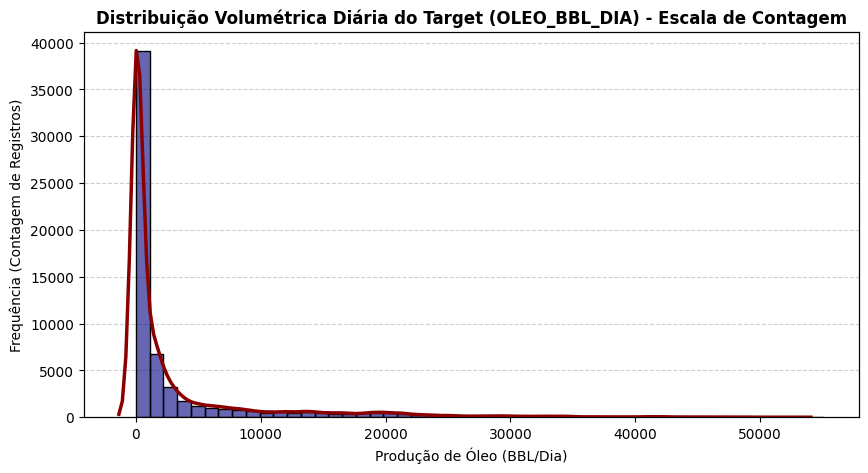

Coeficiente de Assimetria (Skewness) do Target: 3.14


In [17]:
# === 4.1.1 Gráfico de Distribuição do Target (Ajustado para Contagem Real e Grade) ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

target_col = "OLEO_BBL_DIA"

# 1. Tratamento numérico da coluna
df_plot = df[[target_col]].copy()
if df_plot[target_col].dtype == 'object':
    df_plot[target_col] = df_plot[target_col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)

df_plot[target_col] = pd.to_numeric(df_plot[target_col], errors='coerce')
df_plot = df_plot.dropna()

# Amostragem estratégica para evitar travamento no cálculo do KDE
if len(df_plot) > 20000:
    df_amostra = df_plot.sample(n=20000, random_state=42)
else:
    df_amostra = df_plot

# 2. Configuração e Renderização Gráfica
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotamos as barras de contagem real no eixo principal (ax1)
sns.histplot(data=df_plot, x=target_col, color="navy", bins=50, stat="count", alpha=0.6, ax=ax1)

# Ativamos e forçamos as linhas de grade horizontais especificamente no eixo principal (ax1)
ax1.grid(visible=True, axis='y', linestyle='--', alpha=0.6, zorder=0)
ax1.set_axisbelow(True) # Garante que as linhas fiquem atrás das barras azuis

# Criamos o eixo secundário invisível apenas para calcular a proporção da curva vermelha (KDE)
ax2 = ax1.twinx()
sns.kdeplot(data=df_amostra, x=target_col, color="darkred", linewidth=2.5, ax=ax2, bw_adjust=0.5)
ax2.get_yaxis().set_visible(False) # Oculta o eixo Y secundário para evitar poluição visual

# Títulos e Labels formatados
ax1.set_title(f"Distribuição Volumétrica Diária do Target ({target_col}) - Escala de Contagem", fontsize=12, fontweight="bold")
ax1.set_xlabel("Produção de Óleo (BBL/Dia)", fontsize=10)
ax1.set_ylabel("Frequência (Contagem de Registros)", fontsize=10)

plt.show()

# 3. Cálculo da assimetria
skewness = df_plot[target_col].skew()
print(f"Coeficiente de Assimetria (Skewness) do Target: {skewness:.2f}")

O gráfico acima nos mostra que a variável alvo (OLEO_BBL_DIA) possui uma forte assimetria positiva, com um grande acúmulo de registros próximos a zero (representando poços maduros ou de baixa produtividade) e uma cauda longa à direita (representando poços hiper-produtores do Pré-Sal). Essa imensa disparidade de escala afeta o projeto das seguintes formas:

**Escolha do Algoritmo:** Para evitar instabilidades causadas pela assimetria e amplitude dos dados em modelos lineares ou redes neurais, o MVP direciona-se para algoritmos baseados em árvores e conjuntos (ensembles), como XGBoost, LightGBM ou Random Forest, que são naturalmente robustos a esses cenários de desbalanceamento.

**Métrica de Avaliação:** Consolida o uso do WAPE como métrica de sucesso, pois ela pondera os erros de previsão de acordo com o volume real de barris produzidos, impedindo que os inúmeros poços de baixa produção mascarem o real desempenho do modelo nos poços gigantes.

#### 4.1.2 Distribuição de Variáveis Importantes do Ecossistema (Gás e Condensado)
Embora o modelo preditivo seja focado unicamente no target de óleo, as curvas de produção associadas (`CONDENSADO_BBL_DIA` e `GAS_NATURAL_MM3_DIA_TOTAL`) atuam como indicadores fundamentais da dinâmica de fluidos do reservatório e comportamento das bacias. Investigar suas distribuições permite entender o perfil de saturação e correlação física das zonas de extração de mar que foram preservadas no pipeline.


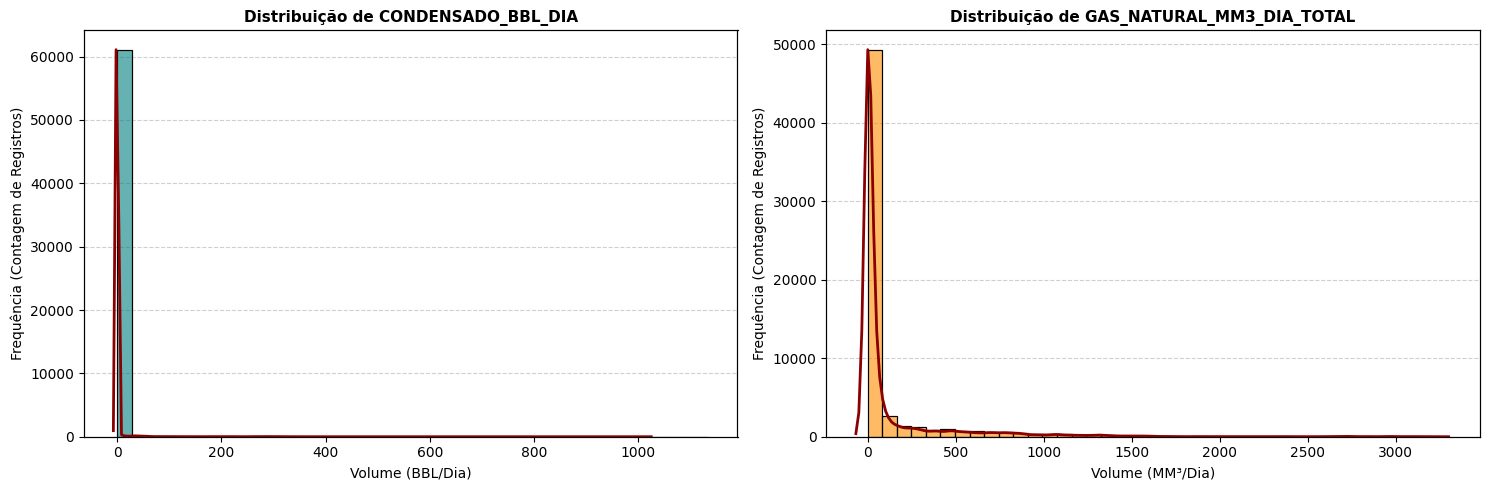

In [19]:
# === 4.1.2 Gráfico de Variáveis Importantes (Gás e Condensado com Grade e KDE) ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

target_condensado = "CONDENSADO_BBL_DIA"
target_gas = "GAS_NATURAL_MM3_DIA_TOTAL"

# 1. Tratamento numérico preventivo para evitar loops e travamentos de memória
df_plot_vars = df[[target_condensado, target_gas]].copy()

for col in [target_condensado, target_gas]:
    if df_plot_vars[col].dtype == 'object':
        df_plot_vars[col] = df_plot_vars[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df_plot_vars[col] = pd.to_numeric(df_plot_vars[col], errors='coerce')

df_plot_vars = df_plot_vars.dropna()

# Amostragem otimizada para o cálculo instantâneo do KDE nas duas curvas
if len(df_plot_vars) > 20000:
    df_amostra_vars = df_plot_vars.sample(n=20000, random_state=42)
else:
    df_amostra_vars = df_plot_vars

# 2. Configuração da janela gráfica lado a lado
fig, (ax_cond, ax_gas) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRÁFICO 1: CONDENSADO ---
sns.histplot(data=df_plot_vars, x=target_condensado, color="teal", bins=40, stat="count", alpha=0.6, ax=ax_cond)
ax_cond.grid(visible=True, axis='y', linestyle='--', alpha=0.6, zorder=0)
ax_cond.set_axisbelow(True)

ax_cond_kde = ax_cond.twinx()
sns.kdeplot(data=df_amostra_vars, x=target_condensado, color="darkred", linewidth=2, ax=ax_cond_kde, bw_adjust=0.5)
ax_cond_kde.get_yaxis().set_visible(False)

ax_cond.set_title("Distribuição de CONDENSADO_BBL_DIA", fontsize=11, fontweight="bold")
ax_cond.set_xlabel("Volume (BBL/Dia)")
ax_cond.set_ylabel("Frequência (Contagem de Registros)")

# --- GRÁFICO 2: GÁS NATURAL TOTAL ---
sns.histplot(data=df_plot_vars, x=target_gas, color="darkorange", bins=40, stat="count", alpha=0.6, ax=ax_gas)
ax_gas.grid(visible=True, axis='y', linestyle='--', alpha=0.6, zorder=0)
ax_gas.set_axisbelow(True)

ax_gas_kde = ax_gas.twinx()
sns.kdeplot(data=df_amostra_vars, x=target_gas, color="darkred", linewidth=2, ax=ax_gas_kde, bw_adjust=0.5)
ax_gas_kde.get_yaxis().set_visible(False)

ax_gas.set_title("Distribuição de GAS_NATURAL_MM3_DIA_TOTAL", fontsize=11, fontweight="bold")
ax_gas.set_xlabel("Volume (MM³/Dia)")
ax_gas.set_ylabel("Frequência (Contagem de Registros)")

plt.tight_layout()
plt.show()

> O gráfico acima nos mostra que as curvas de gás e condensado possuem alta assimetria positiva, com forte concentração de valores próximos a zero devido à baixa Razão Gás-Óleo (RGO) de diversos poços. Esse comportamento estatístico influencia o projeto das seguintes formas:
>
> * **Escolha do Algoritmo:** A presença maciça de zeros e a dispersão dessas variáveis gerariam ruídos se inseridas como preditores lineares simples, reforçando a preferência por algoritmos baseados em árvores e ensembles para capturar relações não-lineares.
> * **Estratégia do Pipeline:** Esse padrão valida a decisão de governança (item 3.3.5) de manter estas variáveis preservadas no ecossistema para filtros e visões de negócio, mas removidas do treinamento do modelo preditivo monovariável de óleo.

#### 4.1.3 Relação entre Preditores Temporais e o Target (Comportamento de Declínio)
As séries temporais baseiam-se na evolução cronológica das variáveis. Nesta etapa, analisamos a relação macro entre a linha do tempo histórica do ecossistema do MVP (2005 a 2025) e o comportamento volumétrico do target para identificar tendências globais de declínio ou expansão da produção.

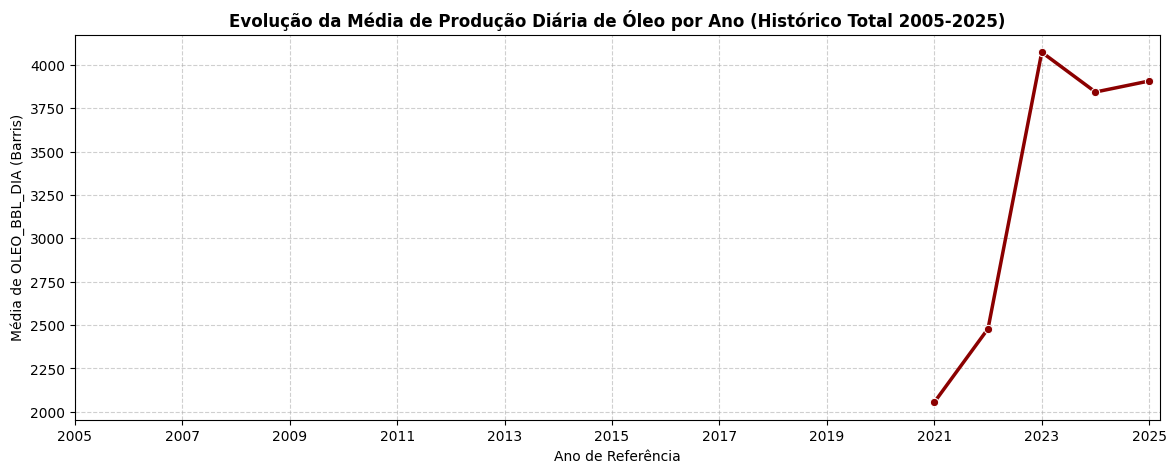

In [23]:
# === 4.1.3 Relação Temporal com o Target (Histórico Completo 2005-2025) ===

col_ano = "ANO_REFERENCIA"
col_oleo = "OLEO_BBL_DIA"

# 1. Isolamos as colunas necessárias
df_temporal = df[[col_ano, col_oleo]].copy()

# Tratamento ultra robusto para o ANO: remove decimais, pontos e espaços antes de converter
df_temporal[col_ano] = df_temporal[col_ano].astype(str).str.split('.').str[0]
df_temporal[col_ano] = pd.to_numeric(df_temporal[col_ano], errors='coerce')

# Tratamento para o ÓLEO
if df_temporal[col_oleo].dtype == 'object':
    df_temporal[col_oleo] = df_temporal[col_oleo].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df_temporal[col_oleo] = pd.to_numeric(df_temporal[col_oleo], errors='coerce')

# Remove apenas o que realmente não foi possível recuperar
df_temporal = df_temporal.dropna()

# Força o ano a ser inteiro puro
df_temporal[col_ano] = df_temporal[col_ano].astype(int)

# Agrupa a produção de óleo média por ano
df_tendencia = df_temporal.groupby(col_ano)[col_oleo].mean().reset_index()

# 2. Renderização Gráfica do Horizonte Total
plt.figure(figsize=(14, 5))

sns.lineplot(data=df_tendencia, x=col_ano, y=col_oleo, marker="o", color="darkred", linewidth=2.5)

plt.title("Evolução da Média de Produção Diária de Óleo por Ano (Histórico Total 2005-2025)", fontsize=12, fontweight="bold")
plt.xlabel("Ano de Referência", fontsize=10)
plt.ylabel("Média de OLEO_BBL_DIA (Barris)", fontsize=10)

# Define o intervalo do eixo X de 2005 até 2025 de 2 em 2 anos para não embolar
plt.xticks(range(2005, 2026, 2))

# Ativação da grade de leitura
plt.grid(visible=True, linestyle='--', alpha=0.6)

plt.show()

> O gráfico acima nos mostra que a produção média de óleo apresenta oscilações marcantes ao longo das décadas, alternando ciclos de forte crescimento (entrada de novos poços e sistemas de produção no Pré-Sal) com inclinações de queda que evidenciam o declínio natural de pressão dos reservatórios de mar. Esse comportamento influencia o projeto das seguintes formas:
>
> * **Escolha do Algoritmo:** A forte característica não-linear e a presença de ciclos temporais plurianuais reforçam que regressões lineares simples seriam insuficientes, justificando o uso de algoritmos baseados em árvores estruturadas para mapear essas quebras de tendência.
> * **Estratégia do Pipeline:** Esse padrão exige a aplicação de uma validação cruzada do tipo *Time Series Split* para evitar vazamento de dados do futuro. Além disso, impõe a necessidade de criar atributos defasados (*lags*) e janelas deslizantes (*rolling windows*) na engenharia de features, fornecendo ao modelo a memória física necessária para prever o comportamento de declínio da curva.